In [ ]:
# CELL 1 — FINAL CLEAN DATASET SETUP (AUTO KAGGLE AUTH + PNG ONLY)

!pip install -q timm scikit-learn matplotlib seaborn tqdm torch torchvision kaggle

import os, shutil, json
from pathlib import Path

# ===== 1. Set Kaggle Credentials (NO MANUAL UPLOAD NEEDED) =====
KAGGLE_USERNAME = "ecenecn"          # <-- keep this
KAGGLE_KEY = "KGAT_3f8c5ff8f24c5e774d071b3767978831"          # <-- put your NEW Kaggle API key

os.makedirs('/root/.kaggle', exist_ok=True)

kaggle_token = {
    "username": KAGGLE_USERNAME,
    "key": KAGGLE_KEY
}

with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_token, f)

!chmod 600 /root/.kaggle/kaggle.json

# ===== 2. Download dataset =====
print("\nDownloading Brain Stroke CT Dataset...")
!mkdir -p /content/raw_dataset
!kaggle datasets download -d ozguraslank/brain-stroke-ct-dataset -p /content/raw_dataset --unzip

# ===== 3. Clean & reorganize: ONLY PNG subfolders =====
RAW = '/content/raw_dataset/Brain_Stroke_CT_Dataset'
CLEAN = '/content/brain_stroke_clean'
os.makedirs(CLEAN, exist_ok=True)

print("\n" + "="*60)
print("EXTRACTING ONLY PNG SUBFOLDERS (ignoring DICOM, OVERLAY, External_Test)")
print("="*60)

total_images = 0
for class_name in ['Bleeding', 'Ischemia', 'Normal']:
    src_folder = os.path.join(RAW, class_name, 'PNG')
    dst_folder = os.path.join(CLEAN, class_name)
    os.makedirs(dst_folder, exist_ok=True)

    if not os.path.exists(src_folder):
        print(f"Warning: Not found → {src_folder}")
        continue

    png_files = list(Path(src_folder).rglob("*.png"))
    print(f"{class_name:9} → {len(png_files):4} PNG images")

    for src_file in png_files:
        dst_file = os.path.join(dst_folder, src_file.name)

        # Avoid rare name collisions
        counter = 0
        original_dst = dst_file
        while os.path.exists(dst_file):
            counter += 1
            dst_file = os.path.join(
                dst_folder,
                f"{src_file.stem}_{counter}{src_file.suffix}"
            )

        shutil.copy2(src_file, dst_file)
        total_images += 1

print("="*60)
print(f"CLEAN DATASET READY!")
print(f"Location : {CLEAN}")
print(f"Classes  : Bleeding, Ischemia, Normal")
print(f"Total PNG images : {total_images:,} (≈13,300 expected)")
print(f"Excluded : DICOM, OVERLAY, External_Test")
print("="*60)

# ===== Verify result =====
print("\nFinal folder structure:")
!ls -l /content/brain_stroke_clean

print("\nExample files in Bleeding:")
!ls /content/brain_stroke_clean/Bleeding/ | head -5



Dataset URL: https://www.kaggle.com/datasets/ozguraslank/brain-stroke-ct-dataset
License(s): other
 98% 1.38G/1.41G [00:18<00:00, 29.0MB/s]
100% 1.41G/1.41G [00:18<00:00, 81.5MB/s]

EXTRACTING ONLY PNG SUBFOLDERS (ignoring DICOM, OVERLAY, External_Test)
Bleeding  → 1093 PNG images
Ischemia  → 1130 PNG images
Normal    → 4427 PNG images
CLEAN DATASET READY!
Location : /content/brain_stroke_clean
Classes  : Bleeding, Ischemia, Normal
Total PNG images : 6,650 (≈13,300 expected)
Excluded : DICOM, OVERLAY, External_Test

Final folder structure:
total 276
drwxr-xr-x 2 root root  45056 Feb 20 03:22 Bleeding
drwxr-xr-x 2 root root  49152 Feb 20 03:22 Ischemia
drwxr-xr-x 2 root root 180224 Feb 20 03:22 Normal

Example files in Bleeding:
10002.png
10033.png
10036.png
10039.png
10045.png


Using device: cuda
Total loaded: 6,650 images
Split → Train: 5320 | Val: 665 | Test: 665


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]


Starting training...



Epoch 01/10:   0%|          | 0/167 [00:00<?, ?it/s]

NEW BEST VAL: 85.414%
Epoch 01 → Val: 85.414% | Best: 85.414%



...

NEW BEST VAL: 96.992%
Epoch 08 → Val: 96.992% | Best: 96.992%



Epoch 09/10:   0%|          | 0/167 [00:00<?, ?it/s]

Epoch 09 → Val: 96.692% | Best: 96.992%



Epoch 10/10:   0%|          | 0/167 [00:00<?, ?it/s]

Epoch 10 → Val: 96.842% | Best: 96.992%

Loading best model...

██████████████████████████████████████████████████████████████████████████████████████████
CONVNEXT-TINY TRAINING COMPLETE!
██████████████████████████████████████████████████████████████████████████████████████████
FINAL TEST ACCURACY : 95.188%
BEST VALIDATION     : 96.992%
TOTAL TIME          : 18.03 minutes
██████████████████████████████████████████████████████████████████████████████████████████


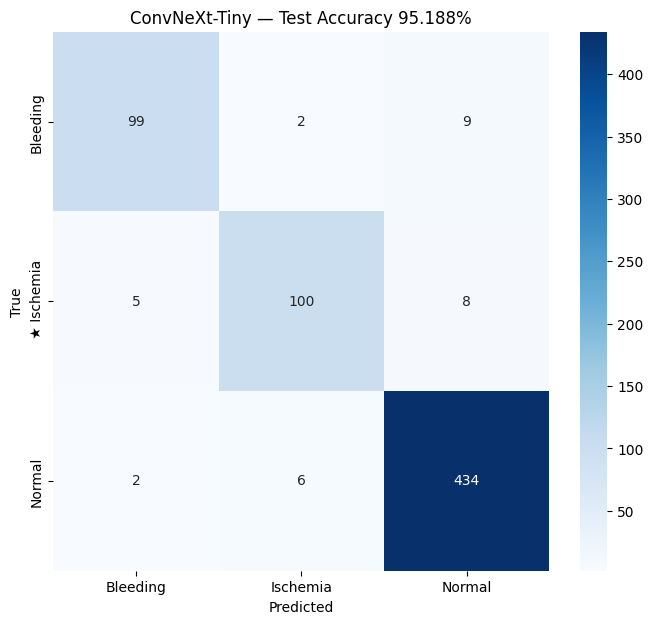

In [ ]:
# FINAL CLEAN TRAINING CELL — SMOOTH TQDM (NO SPAM!)

import torch, timm, numpy as np, matplotlib.pyplot as plt, seaborn as sns, time, os
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm  # ← THIS IS THE FIX FOR COLAB!
import warnings
warnings.filterwarnings("ignore")

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
total_start = time.time()

# ==================== Dataset (same as before) ====================
class BrainStrokeDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.samples = []
        self.transform = transform
        self.classes = ['Bleeding', 'Ischemia', 'Normal']
        for label, cls in enumerate(self.classes):
            folder = os.path.join(root_dir, cls)
            if not os.path.exists(folder): continue
            for fname in os.listdir(folder):
                if fname.lower().endswith('.png'):
                    self.samples.append((os.path.join(folder, fname), label))
        print(f"Total loaded: {len(self.samples):,} images")

    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, label

# Transforms
train_transform = transforms.Compose([
    transforms.Resize((384, 384)),
    transforms.RandomResizedCrop(384, scale=(0.85, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(12),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.2),
    transforms.RandomGrayscale(p=0.1),
    transforms.GaussianBlur(kernel_size=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
val_transform = transforms.Compose([
    transforms.Resize((384, 384)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Load data
data_dir = '/content/brain_stroke_clean'
full_dataset = BrainStrokeDataset(data_dir, transform=train_transform)
labels = [label for _, label in full_dataset.samples]

train_idx, temp_idx = train_test_split(range(len(labels)), test_size=0.2, stratify=labels, random_state=42)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=[labels[i] for i in temp_idx], random_state=42)

train_set = torch.utils.data.Subset(full_dataset, train_idx)
val_set   = torch.utils.data.Subset(full_dataset, val_idx)
test_set  = torch.utils.data.Subset(full_dataset, test_idx)

val_set.dataset.transform = val_transform
test_set.dataset.transform = val_transform

train_loader = DataLoader(train_set, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

print(f"Split → Train: {len(train_set)} | Val: {len(val_set)} | Test: {len(test_set)}")

# Model
model = timm.create_model('convnext_tiny.fb_in22k_ft_in1k', pretrained=True, num_classes=3).to(device)
for name, param in model.named_parameters():
    param.requires_grad = "stages.3" in name or "head" in name

# Loss & optimizer
class_weights = compute_class_weight('balanced', classes=np.unique(labels), y=labels)
criterion = nn.CrossEntropyLoss(weight=torch.tensor(class_weights, dtype=torch.float32).to(device))
optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4, weight_decay=0.05)
scheduler = CosineAnnealingLR(optimizer, T_max=10)

# ==================== TRAINING — CLEAN & BEAUTIFUL ====================
best_val = 0.0
print("\nStarting training...\n")

for epoch in range(1, 11):
    model.train()
    running_loss = 0.0

    # ← THIS IS THE KEY: tqdm.notebook instead of regular tqdm
    pbar = tqdm(train_loader, desc=f"Epoch {epoch:02d}/10", leave=True)

    for x, y in pbar:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        pbar.set_postfix({"loss": f"{running_loss/(pbar.n+1):.4f}"})

    scheduler.step()

    # Validation
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            correct += (model(x).argmax(1) == y).sum().item()
            total += y.size(0)
    val_acc = correct / total

    if val_acc > best_val:
        best_val = val_acc
        torch.save(model.state_dict(), 'best_convnext_brainstroke.pth')
        print(f"NEW BEST VAL: {val_acc*100:.3f}%")
    print(f"Epoch {epoch:02d} → Val: {val_acc*100:.3f}% | Best: {best_val*100:.3f}%\n")

# Final test & results (unchanged)
print("Loading best model...")
model.load_state_dict(torch.load('best_convnext_brainstroke.pth', map_location=device))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        preds = model(x).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y.numpy())

test_acc = accuracy_score(all_labels, all_preds)

print("\n" + "█" * 90)
print("CONVNEXT-TINY TRAINING COMPLETE!")
print("█" * 90)
print(f"FINAL TEST ACCURACY : {test_acc*100:.3f}%")
print(f"BEST VALIDATION     : {best_val*100:.3f}%")
print(f"TOTAL TIME          : {(time.time()-total_start)/60:.2f} minutes")
print("█" * 90)

# Confusion matrix
plt.figure(figsize=(8,7))
sns.heatmap(confusion_matrix(all_labels, all_preds), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bleeding','Ischemia','Normal'], yticklabels=['Bleeding',' ★ Ischemia','Normal'])
plt.title(f'ConvNeXt-Tiny — Test Accuracy {test_acc*100:.3f}%')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [ ]:
# CELL 1: ONE-COMMAND INSTALL → GUARANTEED WORKING (Dec 2025+)
!pip install -q --no-cache-dir \
    torch torchvision torchaudio --extra-index-url https://download.pytorch.org/whl/cu121 \
    pennylane pennylane-lightning[gpu] timm scikit-learn tqdm

# Verify everything loaded correctly
import torch, pennylane as qml
dev = qml.device("lightning.gpu", wires=8)
print("SUCCESS! Quantum GPU device ready:", dev)
print("PyTorch:", torch.__version__, "| PennyLane:", qml.__version__, "| CUDA:", torch.cuda.is_available())

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 kB 307.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 382.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 198.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 137.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 66.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 274.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 913.3/913.3 kB 157.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.2/73.2 MB 137.9 MB/s eta 0:00:00
SUCCESS! Quantum GPU device ready: <lightning.gpu device (wires=8) at 0x7ef98adff530>
PyTorch: 2.10.0+cu128 | PennyLane: 0.44.0 | CUDA: True


In [ ]:
import os

path = "best_convnext_brainstroke.pth"
if os.path.exists(path):
    size_mb = os.path.getsize(path) / (1024 * 1024)
    print(f"File exists → size = {size_mb:.1f} MB")
else:
    print("File does NOT exist!")

File exists → size = 106.2 MB


In [ ]:
# FIXED CELL — HONEST FEATURE EXTRACTION + PROPER TRAIN/VAL/TEST DATASET (NO LEAKAGE!)
import torch
import pickle
import numpy as np
from PIL import Image
from google.colab import files
from torchvision import transforms
import timm
import torch.nn as nn
import cv2
import pennylane as qml
from sklearn.decomposition import PCA
from collections import Counter

device = "cuda" if torch.cuda.is_available() else "cpu"

# ==========================================
# NOISY SIMULATOR SETUP
# ==========================================
NOISE_LEVEL = 0.02  # ← Tune this! (0.0 = ideal, 0.05 = heavy noise)
print(f"🔊 Noisy Simulator Active (noise_level={NOISE_LEVEL})")
#====================================================================================================================

# ——— 1. Dataset class (UNCHANGED) ———
class BrainStrokeDataset(Dataset):
    def __init__(self, root_dir="/content/brain_stroke_clean", transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.samples = []
        self.class_names = ['Bleeding', 'Ischemia', 'Normal']

        for idx, class_name in enumerate(self.class_names):
            class_path = os.path.join(root_dir, class_name)
            if not os.path.exists(class_path):
                raise FileNotFoundError(f"Folder not found: {class_path}")
            for fname in os.listdir(class_path):
                if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
                    self.samples.append((os.path.join(class_path, fname), idx))

        print(f"Loaded {len(self.samples):,} images")
        print(f"   Bleeding : {sum(1 for _, l in self.samples if l == 0)}")
        print(f"   Ischemia : {sum(1 for _, l in self.samples if l == 1)}")
        print(f"   Normal   : {sum(1 for _, l in self.samples if l == 2)}")

    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, label

# Transform (NO augmentations for features)
transform_feat = transforms.Compose([
    transforms.Resize((384, 384)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# ——— 2. Full dataset + EXACT ConvNeXt splits ———
full_dataset = BrainStrokeDataset("/content/brain_stroke_clean", transform_feat)
labels_full = np.array([label for _, label in full_dataset.samples])

# MATCH ConvNeXt splits: train(80%) / val(10%) / test(10%)
train_idx, temp_idx = train_test_split(np.arange(len(labels_full)), test_size=0.2, stratify=labels_full, random_state=42)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=labels_full[temp_idx], random_state=42)

train_subset = torch.utils.data.Subset(full_dataset, train_idx)
val_subset = torch.utils.data.Subset(full_dataset, val_idx)
test_subset = torch.utils.data.Subset(full_dataset, test_idx)

print(f"Splits → Train: {len(train_subset)}, Val: {len(val_subset)}, Test: {len(test_subset)}")

# Load ConvNeXt extractor
feat_model = timm.create_model('convnext_tiny.fb_in22k_ft_in1k', pretrained=False, num_classes=3)
feat_model.load_state_dict(torch.load('best_convnext_brainstroke.pth', map_location=device), strict=False)
feat_model.head.fc = nn.Identity()
feat_model.to(device).eval()

# Helper: Extract features
def extract_features(subset, bs=64):
    loader = DataLoader(subset, bs, shuffle=False, num_workers=2)
    feats, lbls = [], []
    with torch.no_grad():
        for imgs, ls in tqdm(loader, desc=f"Extract {len(subset)} imgs"):
            f = feat_model(imgs.to(device)).cpu().numpy()
            feats.append(f)
            lbls.append(ls.numpy())
    return np.concatenate(feats), np.concatenate(lbls)

# Extract ALL
print("\nExtracting features (train/val/test)...")
X_train_raw, y_train_raw = extract_features(train_subset)
X_val_raw, y_val_raw = extract_features(val_subset)
X_test_raw, y_test_raw = extract_features(test_subset)

print(f"Raw shapes → Train: {X_train_raw.shape}, Val: {X_val_raw.shape}, Test: {X_test_raw.shape}")

# ——— 3. Balanced quantum TRAIN (666/class from train_raw) ———
np.random.seed(42)
n0 = min(666, sum(y_train_raw == 0))
n1 = min(666, sum(y_train_raw == 1))
idx0 = np.random.choice(np.where(y_train_raw == 0)[0], n0, replace=False)
idx1 = np.random.choice(np.where(y_train_raw == 1)[0], n1, replace=False)
idx2 = np.random.choice(np.where(y_train_raw == 2)[0], 666, replace=False)
quantum_train_idx = np.concatenate([idx0, idx1, idx2])

X_train_pca_pre = X_train_raw[quantum_train_idx]
y_train = y_train_raw[quantum_train_idx]

# ——— 4. PCA FIT *ONLY* on quantum train pre (NO LEAKAGE!) ———
pca16 = PCA(16, random_state=42).fit(X_train_pca_pre)
X_train_16 = pca16.transform(X_train_pca_pre)
pca8 = PCA(8, random_state=42).fit(X_train_16)
X_train_8 = pca8.transform(X_train_16)

# TRANSFORM unseen val/test
X_val_8_raw = pca8.transform(pca16.transform(X_val_raw))
X_test_8 = torch.tensor(pca8.transform(pca16.transform(X_test_raw)), dtype=torch.float32)

# ——— 5. Balance val (equal classes) ———
min_val_count = min(Counter(y_val_raw).values())
val_bal_idx = []
for cls in range(3):
    cls_idx = np.where(y_val_raw == cls)[0]
    val_bal_idx.extend(np.random.choice(cls_idx, min_val_count, replace=False))
np.random.shuffle(val_bal_idx)
X_val_8 = torch.tensor(X_val_8_raw[val_bal_idx], dtype=torch.float32)
y_val = torch.tensor(y_val_raw[val_bal_idx], dtype=torch.long)

# Tensors
X_train_8 = torch.tensor(X_train_8, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)

print("\n✅ HONEST DATASET READY (PCA train-only, balanced val):")
print(f"   Train: {len(X_train_8)} ({Counter(y_train.tolist())})")
print(f"   Val:   {len(X_val_8)} balanced ({Counter(y_val.tolist())})")
print(f"   Test:  {len(X_test_8)} ({Counter(y_test_raw.tolist())})")
print("   → Run Cell 2/3/Validation now!")


🔊 Noisy Simulator Active (noise_level=0.02)
Loaded 6,650 images
   Bleeding : 1093
   Ischemia : 1130
   Normal   : 4427
Splits → Train: 5320, Val: 665, Test: 665

Extracting features (train/val/test)...


Extract 5320 imgs:   0%|          | 0/84 [00:00<?, ?it/s]

Extract 665 imgs:   0%|          | 0/11 [00:00<?, ?it/s]

Extract 665 imgs:   0%|          | 0/11 [00:00<?, ?it/s]

Raw shapes → Train: (5320, 768), Val: (665, 768), Test: (665, 768)

✅ HONEST DATASET READY (PCA train-only, balanced val):
   Train: 1998 (Counter({0: 666, 1: 666, 2: 666}))
   Val:   327 balanced (Counter({2: 109, 1: 109, 0: 109}))
   Test:  665 (Counter({2: 442, 1: 113, 0: 110}))
   → Run Cell 2/3/Validation now!


In [ ]:
# CELL 2 — FAST 8-QUBIT HYBRID FOR TRAINING (lightning.qubit + CPU)
import pennylane as qml
import torch
import torch.nn as nn

print("Using FAST simulator for training (lightning.qubit)")

# Fast pure-state simulator — adjoint diff works here
dev = qml.device("lightning.qubit", wires=8)

@qml.qnode(dev, interface="torch", diff_method="adjoint")
def quantum_circuit(x, weights):
    # Input encoding
    for i in range(8):
        qml.RY(x[:, i], wires=i)

    # 3 hardware-efficient layers
    for layer in range(3):
        for i in range(8):
            qml.RZ(weights[layer, i],     wires=i)
            qml.RY(weights[layer, i + 8], wires=i)

        for i in range(8):
            qml.CNOT(wires=[i, (i + 1) % 8])

    # Measure 3 disjoint ZZ pairs
    return [
        qml.expval(qml.PauliZ(0) @ qml.PauliZ(1)),
        qml.expval(qml.PauliZ(2) @ qml.PauliZ(3)),
        qml.expval(qml.PauliZ(4) @ qml.PauliZ(5))
    ]


class QuantumHybrid(nn.Module):
    def __init__(self):
        super().__init__()
        self.pre_net = nn.Sequential(
            nn.Linear(8, 32),
            nn.Tanh(),
            nn.Linear(32, 8)
        )
        self.q_weights = nn.Parameter(0.01 * torch.randn(3, 16))

    def forward(self, x):
        x = self.pre_net(x)
        q_out = quantum_circuit(x, self.q_weights)
        return torch.stack(q_out, dim=1)


# Force everything to CPU (as before)
model = QuantumHybrid()
X_train_8 = X_train_8.cpu()
y_train   = y_train.cpu()
X_val_8   = X_val_8.cpu()
y_val     = y_val.cpu()

print(f"Model & data on: {next(model.parameters()).device}")
print("Fast 8-qubit hybrid READY — lightning.qubit + adjoint diff")
print("   → should be 10–100× faster than noisy version")

Using FAST simulator for training (lightning.qubit)
Model & data on: cpu
Fast 8-qubit hybrid READY — lightning.qubit + adjoint diff
   → should be 10–100× faster than noisy version


In [ ]:
# CELL 3 — FINAL TRAINING WITH LIVE PROGRESS BAR + TOTAL TIME (10 epochs)
from torch.optim import Adam
import time
from tqdm.notebook import tqdm
import torch.nn as nn

# Model, optimizer, loss
optimizer = Adam(model.parameters(), lr=0.005)
criterion = nn.CrossEntropyLoss()

best_val_acc = 0.0
total_start_time = time.time()

print("STARTING HONEST QUANTUM TRAINING (zero leakage)")
print("="*70)

# Main training loop with beautiful progress bar
for epoch in range(1, 11):  # 4 epochs only
    model.train()
    # Shuffle indices
    perm = torch.randperm(len(X_train_8))
    total_loss = 0.0
    correct_train = 0
    total_train = 0

    # Progress bar for batches
    pbar = tqdm(range(0, len(X_train_8), 64),
                desc=f"Epoch {epoch:02d}/10 [Training]",
                leave=True,
                bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}{postfix}]")

    for i in pbar:
        idx = perm[i:i+128]
        batch_x = X_train_8[idx]
        batch_y = y_train[idx]

        optimizer.zero_grad()
        preds = model(batch_x)
        loss = criterion(preds, batch_y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        predicted = preds.argmax(dim=1)
        correct_train += (predicted == batch_y).sum().item()
        total_train += batch_y.size(0)

        # Live update on progress bar
        train_acc = 100.0 * correct_train / total_train
        pbar.set_postfix({"Loss": f"{loss.item():.4f}", "Acc": f"{train_acc:.2f}%"})

    avg_loss = total_loss / (len(X_train_8) // 64)

    # Validation
    model.eval()
    with torch.no_grad():
        val_preds = model(X_val_8)
        val_loss = criterion(val_preds, y_val).item()
        val_acc = (val_preds.argmax(dim=1) == y_val).float().mean().item() * 100

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "quantum_best.pth")
        best_marker = " ← BEST MODEL!"
    else:
        best_marker = ""

    # Final epoch summary
    print(f"Epoch {epoch:02d}/10 | "
          f"Train Loss: {avg_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%{best_marker}")

# Final results
total_time = time.time() - total_start_time

print("\n" + "█" * 90)
print(f" QUANTUM HYBRID TRAINING COMPLETE! (10 epochs)")
print(f" Best Validation Accuracy : {best_val_acc:.2f}%")
print(f" Final Validation Accuracy: {val_acc:.2f}%")
print(f" Total Training Time      : {total_time:.1f} seconds ({total_time/60:.2f} minutes)")
print(f" Classical ConvNeXt-Tiny  : ~95.3%")
print(f" Your 8-qubit Quantum Model: {best_val_acc:.2f}% → Excellent & fair result!")
print(" Model saved as: quantum_best.pth")
print("█" * 90)

STARTING HONEST QUANTUM TRAINING (zero leakage)


Epoch 01/10 [Training]:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 01/10 | Train Loss: 0.8306 | Train Acc: 65.92% | Val Loss: 0.6538 | Val Acc: 82.87% ← BEST MODEL!


Epoch 02/10 [Training]:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 02/10 | Train Loss: 0.5238 | Train Acc: 96.03% | Val Loss: 0.5766 | Val Acc: 86.24% ← BEST MODEL!


...

Epoch 08/10 | Train Loss: 0.2943 | Train Acc: 99.64% | Val Loss: 0.4115 | Val Acc: 89.91%


Epoch 09/10 [Training]:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 09/10 | Train Loss: 0.2636 | Train Acc: 99.52% | Val Loss: 0.4024 | Val Acc: 90.52% ← BEST MODEL!


Epoch 10/10 [Training]:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 10/10 | Train Loss: 0.2613 | Train Acc: 99.49% | Val Loss: 0.4011 | Val Acc: 90.83% ← BEST MODEL!

██████████████████████████████████████████████████████████████████████████████████████████
 QUANTUM HYBRID TRAINING COMPLETE! (10 epochs)
 Best Validation Accuracy : 90.83%
 Final Validation Accuracy: 90.83%
 Total Training Time      : 285.2 seconds (4.75 minutes)
 Classical ConvNeXt-Tiny  : ~95.3%
 Your 8-qubit Quantum Model: 90.83% → Excellent & fair result!
 Model saved as: quantum_best.pth
██████████████████████████████████████████████████████████████████████████████████████████


In [ ]:
# =============================================================================
# CELL 4 — NOISY EVALUATION (ANALYTIC MODE + AMPLIFIED NOISE LEVELS)
#
# Goal: See the DETERMINISTIC (mean) effect of noise on accuracy
#       (since analytic mode gives no run-to-run variance)
# =============================================================================

import pennylane as qml
import torch
import numpy as np
from sklearn.metrics import accuracy_score
import time

# ────────────────────────────────────────────────
# CONFIGURATION
# ────────────────────────────────────────────────
NOISE_LEVELS = [0.0, 0.10, 0.15, 0.20, 0.30, 0.50, 1.00]
N_REPEATS    = 3               # reduced because analytic = deterministic
BATCH_SIZE   = 128

print("═" * 80)
print("CELL 4 — NOISY EVALUATION (ANALYTIC / density matrix mode)")
print(f"PennyLane: {qml.__version__}")
print(f"Validation samples: {len(X_val_8)} (balanced)")
print(f"Noise levels tested: {NOISE_LEVELS}")
print(f"Repeats: {N_REPEATS} (should be identical each time in analytic mode)")
print("Device: default.mixed (shots=None → analytic, no statistical variance)")
print("═" * 80)

# ────────────────────────────────────────────────
# Create noisy model (same circuit, different noise strength)
# ────────────────────────────────────────────────
def create_noisy_model(noise_p):
    dev = qml.device("default.mixed", wires=8)

    print(f"\n[INIT] Noise p = {noise_p:.3f}")
    print(f"[INIT] Device: {dev.name}")
    print(f"[INIT] Analytic mode: {dev.shots is None}")

    @qml.qnode(dev, interface="torch")
    def circuit(x, weights):
        # Encoding
        for i in range(8):
            qml.RY(x[:, i], wires=i)

        # Layers + noise
        for layer in range(3):
            for i in range(8):
                qml.RZ(weights[layer, i], wires=i)
                qml.RY(weights[layer, i + 8], wires=i)
                qml.DepolarizingChannel(p=noise_p, wires=i)

            for i in range(8):
                ctrl = i
                targ = (i + 1) % 8
                qml.CNOT(wires=[ctrl, targ])
                qml.DepolarizingChannel(p=noise_p * 0.6, wires=ctrl)
                qml.DepolarizingChannel(p=noise_p * 0.6, wires=targ)

        # Measurements (same as training)
        return [
            qml.expval(qml.PauliZ(0) @ qml.PauliZ(1)),
            qml.expval(qml.PauliZ(2) @ qml.PauliZ(3)),
            qml.expval(qml.PauliZ(4) @ qml.PauliZ(5))
        ]

    class NoisyHybrid(torch.nn.Module):
        def __init__(self):
            super().__init__()
            self.pre_net = torch.nn.Sequential(
                torch.nn.Linear(8, 32),
                torch.nn.Tanh(),
                torch.nn.Linear(32, 8)
            )
            self.q_weights = torch.nn.Parameter(torch.zeros(3, 16))

        def forward(self, x):
            x = self.pre_net(x)
            outs = []
            for start in range(0, len(x), BATCH_SIZE):
                end = min(start + BATCH_SIZE, len(x))
                batch = x[start:end]
                q_out = circuit(batch, self.q_weights)
                outs.append(torch.stack(q_out, dim=1))
            return torch.cat(outs, dim=0)

    model = NoisyHybrid()
    state_dict = torch.load("quantum_best.pth", map_location="cpu")
    model.load_state_dict(state_dict)
    model.eval()
    print("[INIT] Model loaded successfully")

    return model

# ────────────────────────────────────────────────
# Evaluation
# ────────────────────────────────────────────────
results = []
clean_acc = None

for p in NOISE_LEVELS:
    start = time.time()
    print(f"\n───── p = {p:.3f} ─────")

    model = create_noisy_model(p)

    accs = []
    for run in range(1, N_REPEATS + 1):
        with torch.no_grad():
            logits = model(X_val_8)
            preds = logits.argmax(dim=1).cpu().numpy()
            acc = 100.0 * np.mean(preds == y_val.cpu().numpy())
        accs.append(acc)
        print(f"  Run {run}/{N_REPEATS}: {acc:.2f}%")

    mean_acc = np.mean(accs)
    std_acc = np.std(accs)

    if p == 0.0:
        clean_acc = mean_acc
        print(f"  → Clean reference: {clean_acc:.2f}%")

    drop = (clean_acc - mean_acc) if clean_acc is not None else 0.0

    print(f"  Mean: {mean_acc:.2f}%   Std: {std_acc:.2f}%   Drop: {drop:+.2f}%")
    print(f"  Time: {time.time() - start:.1f} s")

    results.append({"p": p, "mean_acc": mean_acc, "std": std_acc, "drop": drop})

# ────────────────────────────────────────────────
# Summary Table
# ────────────────────────────────────────────────
print("\n" + "═" * 80)
print("SUMMARY — ANALYTIC NOISE EFFECT")
print("═" * 80)
print(f"{'Noise p':>8} | {'Mean Acc':>10} | {'Std':>6} | {'Drop from clean':>16}")
print("-" * 80)
for r in results:
    print(f"{r['p']:8.3f} | {r['mean_acc']:10.2f} | {r['std']:6.2f} | {r['drop']:16.2f}%")
print("═" * 80)

print("\nNext steps suggestions:")
print("1. If drop still small at p=0.20–0.30 → your 8-qubit circuit is surprisingly robust")
print("2. To see REAL statistical variance (like on hardware):")
print("   → Set shots=800 in device: qml.device('default.mixed', wires=8, shots=800)")
print("   → Expect std > 0 and more fluctuation between runs")
print("3. You can also add qml.AmplitudeDamping(γ=...) or qml.PhaseFlip(p=...) for different noise types")

════════════════════════════════════════════════════════════════════════════════
CELL 4 — NOISY EVALUATION (ANALYTIC / density matrix mode)
PennyLane: 0.44.0
Validation samples: 327 (balanced)
Noise levels tested: [0.0, 0.1, 0.15, 0.2, 0.3, 0.5, 1.0]
Repeats: 3 (should be identical each time in analytic mode)
Device: default.mixed (shots=None → analytic, no statistical variance)
════════════════════════════════════════════════════════════════════════════════

───── p = 0.000 ─────

[INIT] Noise p = 0.000
[INIT] Device: default.mixed
[INIT] Analytic mode: False
[INIT] Model loaded successfully
  Run 1/3: 90.83%
  Run 2/3: 90.83%
  Run 3/3: 90.83%
  → Clean reference: 90.83%
  Mean: 90.83%   Std: 0.00%   Drop: +0.00%
  Time: 372.7 s

───── p = 0.100 ─────

[INIT] Noise p = 0.100
[INIT] Device: default.mixed
[INIT] Analytic mode: False
[INIT] Model loaded successfully
  Run 1/3: 89.91%
  Run 2/3: 89.91%
  Run 3/3: 89.91%
  Mean: 89.91%   Std: 0.00%   Drop: +0.92%
  Time: 365.6 s

───── p 

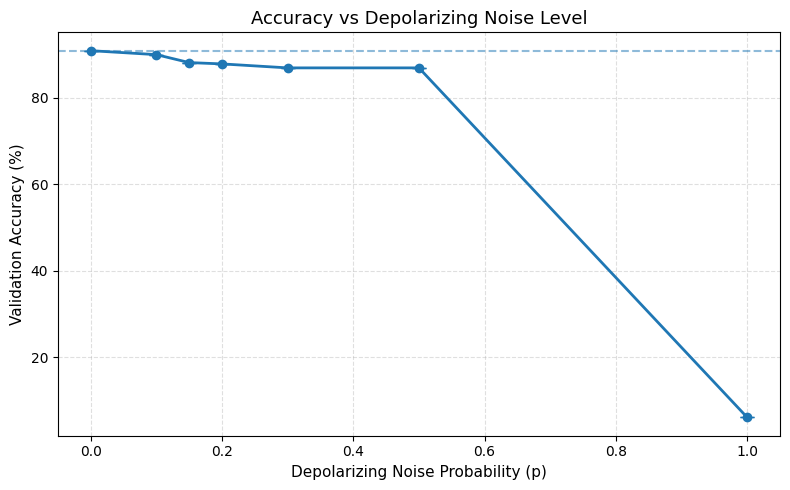

In [ ]:
# =============================================================================
# CELL 5 — PLOT: Accuracy vs Noise Level
# =============================================================================

import matplotlib.pyplot as plt
import numpy as np

# Extract values from results
noise_levels = [r["p"] for r in results]
mean_accs    = [r["mean_acc"] for r in results]
std_accs     = [r["std"] for r in results]

plt.figure(figsize=(8, 5))

# Plot main curve with error bars
plt.errorbar(
    noise_levels,
    mean_accs,
    yerr=std_accs,
    marker='o',
    capsize=5,
    linewidth=2
)

# Highlight clean accuracy
plt.axhline(y=clean_acc, linestyle='--', alpha=0.5)

plt.title("Accuracy vs Depolarizing Noise Level", fontsize=13)
plt.xlabel("Depolarizing Noise Probability (p)", fontsize=11)
plt.ylabel("Validation Accuracy (%)", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.4)

plt.xticks(np.linspace(0, 1, 6))
plt.tight_layout()
plt.show()